### Architecture 3: EfficientNet-B0 (different pretrained backbone)

The third variant is a **different pretrained backbone: ImageNet EfficientNet-B0, fine-tuned**. EfficientNet-B0 has
fewer parameters than ResNet-18 (4.0 M vs 11.2 M) but uses depthwise-separable MBConv blocks with squeeze-and-excitation.
It tests whether a more parameter-efficient backbone matches ResNet-18 on this task. The training recipe is
identical to `resnet18_ft` (new `Dropout(0.3) -> Linear(1280, 4)` head, head lr 1e-3, backbone lr 1e-4, AdamW, cosine
decay, 30 epochs, patience 10, 3 seeds), so any difference comes from the backbone.

#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU` (CPU also works, just slower), then run this cell.
By default it mounts Google Drive and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1`, so results,
logs and checkpoints persist after the session ends. Cloning the private repo needs a GitHub personal access token
saved as a Colab secret named `GITHUB_TOKEN` (key icon in the left sidebar). Locally, the cell just finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")  # Colab secret holding a GitHub access token
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "preprocessing.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print("Project root:", PROJECT_ROOT)
print("PyTorch", torch.__version__, "| device:", "cuda - " + torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
Project root: /content/drive/MyDrive/IE7615-Group3-Project1
PyTorch 2.11.0+cu128 | device: cuda - Tesla T4


#### 1. Import Pre-Processed Data

In [2]:
import pandas as pd
from IPython.display import display
from src.preprocessing import load_splits, split_summary, get_dataloaders

splits = load_splits()  # data/splits.csv, produced by Preprocessing_Pipeline.ipynb
loaders, class_names = get_dataloaders(splits, batch_size=16)
print("Classes:", class_names)
display(split_summary(splits))

Classes: ['id_2336', 'id_2970', 'id_4422', 'id_7007']


split,train,val,test,total
identity,,,,
2336,15,5,5,25
2970,15,5,5,25
4422,15,5,5,25
7007,14,5,5,24
total,59,20,20,99


#### 2. Train Model

**Model.** torchvision's ImageNet-pretrained EfficientNet-B0. Its 1000-class classifier is replaced by
`Dropout(0.3) -> Linear(1280, 4)`, and **all layers are fine-tuned**. The new head starts from random weights and
learns at 1e-3, while the pretrained backbone uses a 10x smaller learning rate (1e-4), so its ImageNet features
adapt to faces without being destroyed early in training. ImageNet weights are downloaded by torchvision on first use.

In [3]:
import torch
from torch import nn
from torchvision import models as tvm


def build_efficientnet_b0(num_classes, pretrained=True):
    """ImageNet EfficientNet-B0 with a new Dropout(0.3) -> Linear(1280, num_classes) head."""
    weights = tvm.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = tvm.efficientnet_b0(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = build_efficientnet_b0(num_classes=len(class_names))
print("New classification head:\n", model.classifier)
total, trainable = count_parameters(model)
head = sum(p.numel() for p in model.classifier.parameters())
print(f"Parameters: {total:,} total, {trainable:,} trainable ({head:,} in the new head)")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 190MB/s]

New classification head:
 Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
Parameters: 4,012,672 total, 4,012,672 trainable (5,124 in the new head)


**Training configuration and helpers.** AdamW with two parameter groups (head / backbone), cosine learning-rate decay,
label smoothing 0.1, up to 30 epochs with early stopping after 10 epochs without validation improvement; the weights
of the best validation epoch are kept. Every seed resets Python, NumPy and PyTorch RNGs and the training
DataLoader's shuffle generator, so runs are reproducible. Results go to `results/milestone1/efficientnet_b0_ft/` and the
representative model to `checkpoints/efficientnet_b0_ft.pt`.

In [4]:
import copy
import json
import math
import platform
import random
import time
from dataclasses import asdict, dataclass

import numpy as np

MODEL_NAME = "efficientnet_b0_ft"
DISPLAY_NAME = "EfficientNet-B0 (fine-tuned)"
SEEDS = (0, 1, 2)
RESULTS_DIR = PROJECT_ROOT / "results" / "milestone1" / MODEL_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"


@dataclass
class TrainConfig:
    epochs: int = 30            # maximum epochs
    head_lr: float = 1e-3       # new classification head
    backbone_lr: float = 1e-4   # pretrained layers (10x smaller)
    weight_decay: float = 1e-4
    label_smoothing: float = 0.1
    patience: int = 10          # early stopping: epochs without validation improvement


cfg = TrainConfig()
print(cfg)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_NAME = (torch.cuda.get_device_name(0) if device.type == "cuda"
               else f"CPU ({platform.processor() or platform.machine()})")
print("Device:", DEVICE_NAME)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def param_groups(model, cfg):
    """Head parameters at cfg.head_lr, pretrained backbone at cfg.backbone_lr."""
    head = [p for n, p in model.named_parameters() if n.startswith("classifier.")]
    backbone = [p for n, p in model.named_parameters() if not n.startswith("classifier.")]
    return [{"params": head, "lr": cfg.head_lr, "weight_decay": cfg.weight_decay},
            {"params": backbone, "lr": cfg.backbone_lr, "weight_decay": cfg.weight_decay}]

TrainConfig(epochs=30, head_lr=0.001, backbone_lr=0.0001, weight_decay=0.0001, label_smoothing=0.1, patience=10)
Device: Tesla T4


In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Loss, accuracy, labels, predictions and softmax probabilities for one split."""
    model.eval()
    total_loss, ys, preds, probs = 0.0, [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        p = logits.softmax(1)
        ys.append(y.cpu())
        preds.append(p.argmax(1).cpu())
        probs.append(p.cpu())
    y_true, y_pred = torch.cat(ys).numpy(), torch.cat(preds).numpy()
    return {"loss": total_loss / len(y_true), "acc": float((y_true == y_pred).mean()),
            "y_true": y_true, "y_pred": y_pred, "probs": torch.cat(probs).numpy()}


def fit(model, loaders, cfg, log_every=5):
    """AdamW (head / backbone LRs) + cosine LR decay with early stopping; restores the best epoch.

    Best = highest validation accuracy, ties broken by lower validation loss.
    Returns (history DataFrame, best epoch, training time in seconds).
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    optimizer = torch.optim.AdamW(param_groups(model, cfg))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    best_acc, best_loss, best_epoch, best_state, wait = -1.0, math.inf, 0, None, 0
    history = []
    start = time.perf_counter()
    for epoch in range(1, cfg.epochs + 1):
        t0 = time.perf_counter()
        train_loss, train_acc = train_one_epoch(model, loaders["train"], criterion, optimizer)
        val = evaluate(model, loaders["val"], criterion)
        lr = optimizer.param_groups[0]["lr"]  # head learning rate
        scheduler.step()
        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val["loss"], "val_acc": val["acc"], "lr": lr,
                        "epoch_time_s": time.perf_counter() - t0})

        if val["acc"] > best_acc or (val["acc"] == best_acc and val["loss"] < best_loss):
            best_acc, best_loss, best_epoch, wait = val["acc"], val["loss"], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if epoch % log_every == 0 or epoch == 1:
            print(f"  epoch {epoch:3d} | train loss {train_loss:.3f} acc {train_acc:.3f} "
                  f"| val loss {val['loss']:.3f} acc {val['acc']:.3f}")
        if wait >= cfg.patience:
            print(f"  early stop at epoch {epoch} (best epoch {best_epoch})")
            break

    train_time = time.perf_counter() - start
    model.load_state_dict(best_state)
    return pd.DataFrame(history), best_epoch, train_time

**Train with 3 seeds.** The split is fixed; the seed changes the new head's initialization, augmentation, dropout
and batch order.

In [6]:
from sklearn.metrics import f1_score

eval_criterion = nn.CrossEntropyLoss()  # plain cross-entropy for reporting
runs, histories, trained_models, test_results = [], {}, {}, {}

for seed in SEEDS:
    print(f"[{MODEL_NAME}] seed {seed}")
    set_seed(seed)
    loaders["train"].generator.manual_seed(seed)
    model = build_efficientnet_b0(num_classes=len(class_names)).to(device)
    history, best_epoch, train_time = fit(model, loaders, cfg)
    val = evaluate(model, loaders["val"], eval_criterion)
    test = evaluate(model, loaders["test"], eval_criterion)

    histories[seed], trained_models[seed], test_results[seed] = history, model, test
    runs.append({
        "seed": seed, "best_epoch": best_epoch, "epochs_run": len(history),
        "train_time_s": train_time, "val_acc": val["acc"], "val_loss": val["loss"],
        "test_acc": test["acc"], "test_loss": test["loss"],
        "test_macro_f1": f1_score(test["y_true"], test["y_pred"], average="macro"),
    })
    print(f"  -> best epoch {best_epoch}, val acc {val['acc']:.3f}, "
          f"test acc {test['acc']:.3f}, train time {train_time:.1f}s")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
for seed, h in histories.items():
    h.to_csv(RESULTS_DIR / f"history_seed{seed}.csv", index=False)  # per-epoch training log

[efficientnet_b0_ft] seed 0
  epoch   1 | train loss 1.339 acc 0.373 | val loss 1.329 acc 0.400
  epoch   5 | train loss 0.835 acc 0.949 | val loss 1.037 acc 0.750
  epoch  10 | train loss 0.570 acc 0.915 | val loss 0.761 acc 0.900
  epoch  15 | train loss 0.403 acc 1.000 | val loss 0.647 acc 0.950
  epoch  20 | train loss 0.411 acc 1.000 | val loss 0.631 acc 0.900
  epoch  25 | train loss 0.431 acc 1.000 | val loss 0.631 acc 0.900
  epoch  30 | train loss 0.398 acc 1.000 | val loss 0.636 acc 0.900
  -> best epoch 21, val acc 0.950, test acc 0.850, train time 44.6s
[efficientnet_b0_ft] seed 1
  epoch   1 | train loss 1.370 acc 0.373 | val loss 1.321 acc 0.450
  epoch   5 | train loss 0.761 acc 0.932 | val loss 0.915 acc 0.750
  epoch  10 | train loss 0.528 acc 0.966 | val loss 0.737 acc 0.800
  epoch  15 | train loss 0.465 acc 0.966 | val loss 0.758 acc 0.750
  epoch  20 | train loss 0.394 acc 1.000 | val loss 0.728 acc 0.750
  early stop at epoch 20 (best epoch 10)
  -> best epoch 10,

#### 3. Evaluate Model
The **representative run** is the seed with the best *validation* accuracy (ties -> lower validation loss). Test metrics are reported as mean ± sd over all seeds, and the confusion matrix is
shown both for the representative run and pooled over all seeds.

Outputs: per-epoch logs `results/milestone1/efficientnet_b0_ft/history_seed*.csv`, metrics
`results/milestone1/efficientnet_b0_ft/metrics.json` (read by `Model_Comparison.ipynb`), per-image predictions
`results/milestone1/efficientnet_b0_ft/test_predictions.csv`, and the representative model `checkpoints/efficientnet_b0_ft.pt`.

In [7]:
import io
from sklearn.metrics import classification_report, confusion_matrix


def model_size_mb(model):
    """Size of the serialised state_dict in MB."""
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return buf.getbuffer().nbytes / 1024**2


@torch.no_grad()
def measure_inference(model, batch_size=1, n_iters=30, image_size=224):
    """Average latency in milliseconds per image."""
    model.eval()
    x = torch.randn(batch_size, 3, image_size, image_size, device=device)
    for _ in range(5):  # warm-up
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(n_iters):
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - start) / (n_iters * batch_size) * 1000


rep = max(runs, key=lambda r: (r["val_acc"], -r["val_loss"]))
rep_seed = rep["seed"]
model, test = trained_models[rep_seed], test_results[rep_seed]

labels = list(range(len(class_names)))
cm = confusion_matrix(test["y_true"], test["y_pred"], labels=labels)
cm_pooled = sum(confusion_matrix(t["y_true"], t["y_pred"], labels=labels) for t in test_results.values())
per_class_seed = np.array([[np.mean(t["y_pred"][t["y_true"] == c] == c) for c in labels]
                           for t in test_results.values()])

test_accs = np.array([r["test_acc"] for r in runs])
f1s = np.array([r["test_macro_f1"] for r in runs])
total_params, trainable_params = count_parameters(model)
metrics = {
    "model": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "device": DEVICE_NAME,
    "config": asdict(cfg),
    "seeds": list(SEEDS),
    "class_names": class_names,
    "n_train": len(loaders["train"].dataset),
    "n_val": len(loaders["val"].dataset),
    "n_test": len(loaders["test"].dataset),
    "params_total": total_params,
    "params_trainable": trainable_params,
    "size_mb": model_size_mb(model),
    "train_time_s_mean": float(np.mean([r["train_time_s"] for r in runs])),
    "time_per_epoch_s": float(np.mean([r["train_time_s"] / r["epochs_run"] for r in runs])),
    "test_acc_mean": float(test_accs.mean()),
    "test_acc_std": float(test_accs.std(ddof=1)),
    "test_macro_f1_mean": float(f1s.mean()),
    "test_macro_f1_std": float(f1s.std(ddof=1)),
    "val_acc_mean": float(np.mean([r["val_acc"] for r in runs])),
    "inference_ms_per_image_bs1": measure_inference(model, batch_size=1),
    "inference_ms_per_image_bs32": measure_inference(model, batch_size=32, n_iters=5),
    "runs": runs,
    "representative_seed": rep_seed,
    "representative_test_acc": rep["test_acc"],
    "per_class_accuracy": dict(zip(class_names, per_class_seed.mean(0).tolist())),
    "per_class_accuracy_representative": dict(zip(class_names, per_class_seed[SEEDS.index(rep_seed)].tolist())),
    "confusion_matrix": cm.tolist(),
    "confusion_matrix_pooled": cm_pooled.tolist(),
    "classification_report": classification_report(
        test["y_true"], test["y_pred"], labels=labels, target_names=class_names,
        output_dict=True, zero_division=0),
}
(RESULTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

preds = pd.DataFrame({
    "path": loaders["test"].dataset.paths,
    "true": [class_names[i] for i in test["y_true"]],
    "pred": [class_names[i] for i in test["y_pred"]],
})
for i, c in enumerate(class_names):
    preds[f"p_{c}"] = test["probs"][:, i]
preds.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({"model_name": MODEL_NAME, "state_dict": model.state_dict(), "class_names": class_names,
            "image_size": 224, "config": asdict(cfg), "seed": rep_seed},
           CHECKPOINT_DIR / f"{MODEL_NAME}.pt")

print(f"{DISPLAY_NAME} - trained on {DEVICE_NAME}")
print(f"Test accuracy: {metrics['test_acc_mean']:.3f} ± {metrics['test_acc_std']:.3f} "
      f"(mean ± sd over seeds {list(SEEDS)}); representative run = seed {rep_seed}")
display(pd.DataFrame(runs).round(3))
display(pd.DataFrame([{
    "Model": DISPLAY_NAME,
    "Test acc (mean ± sd)": f"{metrics['test_acc_mean']:.3f} ± {metrics['test_acc_std']:.3f}",
    "Macro-F1": f"{metrics['test_macro_f1_mean']:.3f}",
    "Params (M)": round(total_params / 1e6, 2),
    "Size (MB)": round(metrics["size_mb"], 1),
    "Train time / run (s)": round(metrics["train_time_s_mean"], 1),
    "Inference (ms/img)": round(metrics["inference_ms_per_image_bs1"], 2),
}]))

EfficientNet-B0 (fine-tuned) - trained on Tesla T4
Test accuracy: 0.800 ± 0.087 (mean ± sd over seeds [0, 1, 2]); representative run = seed 2


,seed,best_epoch,epochs_run,train_time_s,val_acc,val_loss,test_acc,test_loss,test_macro_f1
0,0,21,30,44.619,0.95,0.478,0.85,0.501,0.846
1,1,10,20,20.273,0.80,0.595,0.70,0.628,0.687
2,2,25,30,32.391,1.00,0.410,0.85,0.434,0.844


,Model,Test acc (mean ± sd),Macro-F1,Params (M),Size (MB),Train time / run (s),Inference (ms/img)
0,EfficientNet-B0 (fine-tuned),0.800 ± 0.087,0.792,4.01,15.6,32.4,18.9


**Training curves** (train = dashed, validation = solid; one colour per seed):

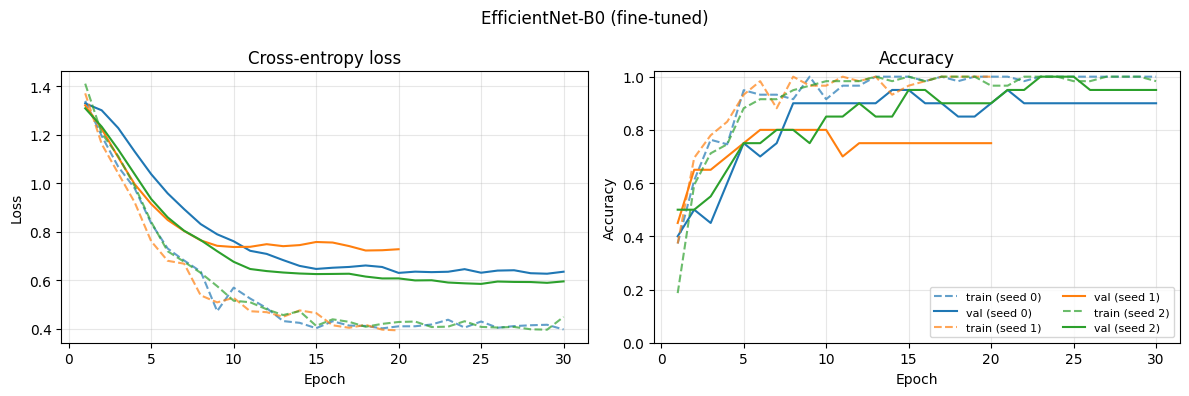

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, (seed, h) in enumerate(histories.items()):
    for ax, metric in zip(axes, ("loss", "acc")):
        ax.plot(h["epoch"], h[f"train_{metric}"], "--", color=colors[i], alpha=0.7, label=f"train (seed {seed})")
        ax.plot(h["epoch"], h[f"val_{metric}"], "-", color=colors[i], label=f"val (seed {seed})")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.02))
for ax in axes:
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8, loc="lower right", ncol=2)
fig.suptitle(DISPLAY_NAME)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")

**Test-set confusion matrix** (counts and row-normalised %; left = representative run chosen by validation accuracy, right = pooled over all seeds):

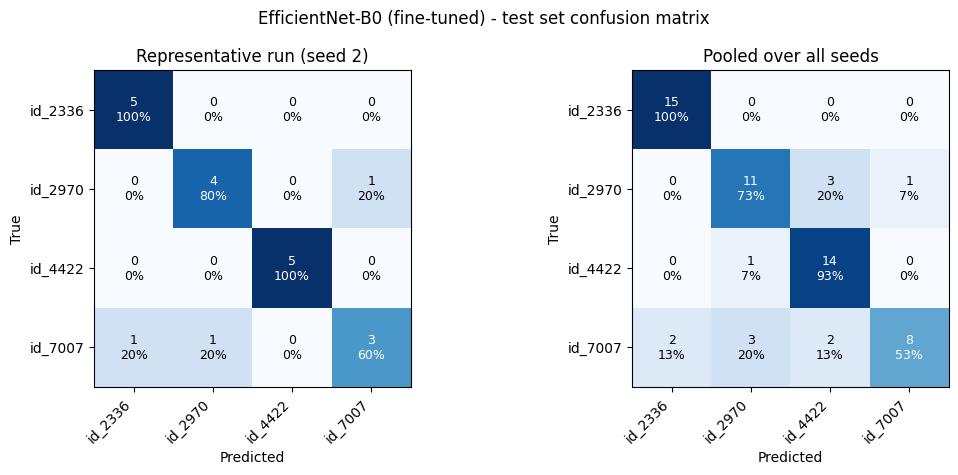

In [9]:
def draw_confusion_matrix(ax, cm, title):
    cm = np.asarray(cm)
    row_pct = cm / cm.sum(1, keepdims=True).clip(min=1)
    ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}\n{row_pct[i, j]:.0%}", ha="center", va="center",
                    color="white" if row_pct[i, j] > 0.5 else "black", fontsize=9)
    ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)), class_names)
    ax.set(xlabel="Predicted", ylabel="True", title=title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
draw_confusion_matrix(axes[0], cm, f"Representative run (seed {rep_seed})")
draw_confusion_matrix(axes[1], cm_pooled, "Pooled over all seeds")
fig.suptitle(f"{DISPLAY_NAME} - test set confusion matrix")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")

In [10]:
print("Per-class test accuracy (mean over seeds):")
display(pd.Series(metrics["per_class_accuracy"], name="accuracy").round(3).to_frame().T)
print("Classification report (representative run):")
display(pd.DataFrame(metrics["classification_report"]).T.round(3))

Per-class test accuracy (mean over seeds):


,id_2336,id_2970,id_4422,id_7007
accuracy,1.0,0.733,0.933,0.533


Classification report (representative run):


,precision,recall,f1-score,support
id_2336,0.833,1.00,0.909,5.00
id_2970,0.800,0.80,0.800,5.00
id_4422,1.000,1.00,1.000,5.00
id_7007,0.750,0.60,0.667,5.00
accuracy,0.850,0.85,0.850,0.85
macro avg,0.846,0.85,0.844,20.00
weighted avg,0.846,0.85,0.844,20.00


#### Observations
*Numbers below are from our Colab run (Tesla T4, seeds 0-2). A rerun can differ; the tables above always show the current run.*

* **Test accuracy 80.0% ± 8.7%** (macro-F1 0.79; per seed 85%, 70% and 85%), with mean validation accuracy 91.7%.
  This is far above the Custom CNN's Colab run (38.3% ± 7.6%). ImageNet pretraining is what makes 14-15 training
  images per identity enough.
* **Fast convergence, one weaker seed.** In every seed, training accuracy reaches ~100% within 8-15 epochs, and
  training loss levels off at ~0.4. That is close to the lowest value possible with label smoothing 0.1 (~0.35), so the
  training set is fully fitted. Validation loss flattens instead of rising, so there is no harmful over-fitting. Seeds 0 and
  2 peak late (best epochs 21 and 25, validation 95-100%, test 85%). Seed 1 plateaued at 80% validation accuracy,
  stopped early at epoch 20 (best epoch 10) and scored 70% on test. That single run is why the spread (8.7 points) is
  larger than in our earlier CPU run of the same code (83.3% ± 2.9%), where GPU and CPU random numbers led to different
  training paths.
* **Identity level (pooled over seeds):** `id_2336` 100% and `id_4422` 93% are recognised almost perfectly, and
  `id_2970` reaches 73% (mostly confused with its look-alike `id_4422`, 3 of 15). `id_7007` is the weakest identity
  (53%): its errors are spread over all three other identities (`id_2970` 3, `id_2336` 2, `id_4422` 2 of 15).
* **Cost:** 4.0 M parameters. 32 s per training run and 18.9 ms/image
  inference at batch size 1 on a T4. At batch size 1, GPU latency is dominated by per-layer overhead, and EfficientNet-B0
  has many small layers.